# dat_col_plotting from pkl
1. get "df_77_97_mrn" from pkl
2. plot_Multiple cols on same axis [ ie col & filtered col]
3. Plot_multi_cols_dual [Individual scalling -- all axis on tr side]
4. Create "plt_lst" = list of columns you want to include in the analysis and plotting
5. Read col names from df_77_97_mrn column names and paste to a list.

# Import Libraries and run defs

In [1]:
# Imports required for Loading, sorting .csx files to create specific data sets ie mrn inbody readings. 
%run ./sys_funcs.py              # loads all the def functions in sys_funcs.py into memory
#import sys_funcs                 # gives access to these def function digitalform that are in memory
from pathlib import Path
import csv
import pandas as pd
import numpy as np
#import tkinter as tk
import pickle
from pathlib import Path
import csv
import os
import sys
from datetime import datetime
from datetime import time
from sys_funcs import read_csv_to_array
from sys_funcs import clean_wsl_path
from sys_funcs import array_to_dt_row_dict
from sys_funcs import make_blnk_update_row_dict
from sys_funcs import transpose_csv_to_col_dict
#from sys_funcs import update_values_with_config, get_update_result
from sys_funcs import transfer_updates
from sys_funcs import get_dtv_range
from sys_funcs import universal_import
from sys_funcs import parse_inbody_timestamp
from sys_funcs import build_lut
from sys_funcs import extract_a_column_as_df
from sys_funcs import extract_multicolumns_as_df
from sys_funcs import validate_and_sort_timestamps
from sys_funcs import extract_and_filter_by_time_window
from sys_funcs import read_file_dual_path
from sys_funcs import write_file_dual_path
from sys_funcs import asc_to_csv_cnv
from collections.abc import Mapping
import re
#from sys_funcs import 

In [2]:
def scale_mean_to_one(series):
    """Scale a Pandas Series so that its mean becomes 1."""
    mean_val = series.mean()
    return series / mean_val

In [3]:
def write_df_to_pickle(df, filename):
    """
    Writes a DataFrame to a pickle file.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe to save.
    filename : str
        The pickle filename, e.g. 'mydata.pkl'.
    """
    df.to_pickle(filename)

# usage 
# write_df_to_pickle(df, "df.pkl")


In [4]:
def plot_2cols(plt_col_a, plt_col_b):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    # Ensure timestamp is datetime
    df = df_mf_ib7797_nn_s_mrn.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    fig, ax = plt.subplots(figsize=(12, 5))

    # Plot first variable
    ax.plot(
        df["timestamp"],
        df[plt_col_a],
        marker="o",
        label=plt_col_a
    )

    # Plot second variable
    ax.plot(
        df["timestamp"],
        df[plt_col_b],
        marker="o",
        label=plt_col_b
    )

    # Minor ticks every day
    ax.xaxis.set_minor_locator(mdates.DayLocator())

    # Major ticks weekly (Mondays)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    # Grid on major ticks
    ax.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.7)

    plt.xticks(rotation=45)
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.title(f"{plt_col_a} & {plt_col_b} over time")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [5]:
def plot_2cols_dual(plt_col_a, plt_col_b):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    # Work on a safe copy
    df = df_mf_ib7797_nn_s_mrn.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # First variable (left y-axis)
    ax1.plot(
        df["timestamp"],
        df[plt_col_a],
        marker="o",
        color="tab:blue",
        label=plt_col_a
    )
    ax1.set_ylabel(plt_col_a, color="tab:blue")

    # Second variable (right y-axis)
    ax2 = ax1.twinx()
    ax2.plot(
        df["timestamp"],
        df[plt_col_b],
        marker="o",
        color="tab:red",
        label=plt_col_b
    )
    ax2.set_ylabel(plt_col_b, color="tab:red")

    # Minor ticks every day
    ax1.xaxis.set_minor_locator(mdates.DayLocator())

    # Major ticks weekly (Mondays)
    ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    # Grid on major ticks
    ax1.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.7)

    plt.xticks(rotation=45)
    plt.title(f"{plt_col_a} and {plt_col_b} over time")
    plt.tight_layout()
    plt.show()


In [6]:
def plot_multi_same_axis(*cols):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    df = df_mf_ib7797_nn_s_mrn.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    fig, ax = plt.subplots(figsize=(12, 5))

    for col in cols:
        ax.plot(df["timestamp"], df[col], marker="o", label=col)

    # Daily minor ticks
    ax.xaxis.set_minor_locator(mdates.DayLocator())

    # Weekly major ticks
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    ax.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.7)

    plt.xticks(rotation=45)
    plt.title(" / ".join(cols) + " over time")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [7]:
def plot_multi_dual(df, *cols):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import pandas as pd

    # Work on a safe copy
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Color cycle (extend if needed)
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(figsize=(12, 5))

    # First column on left axis
    ax.plot(
        df["timestamp"],
        df[cols[0]],
        marker="o",
        color=color_cycle[0],
        label=cols[0]
    )
    ax.set_ylabel(cols[0], color=color_cycle[0])
    ax.tick_params(axis="y", labelcolor=color_cycle[0])
    axes = [ax]

    # Additional columns on stacked right axes
    for i, col in enumerate(cols[1:], start=1):
        ax_new = ax.twinx()
        ax_new.spines.right.set_position(("axes", 1 + 0.1 * (i - 1)))

        color = color_cycle[i % len(color_cycle)]
        ax_new.plot(
            df["timestamp"],
            df[col],
            marker="o",
            color=color,
            label=col
        )
        ax_new.set_ylabel(col, color=color)
        ax_new.tick_params(axis="y", labelcolor=color)

        axes.append(ax_new)

    # Minor ticks every day
    ax.xaxis.set_minor_locator(mdates.DayLocator())

    # Major ticks weekly (Mondays)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    
    # Rotate major tick labels for readability
    for label in ax.get_xticklabels(which="major"):
        label.set_rotation(45)
        label.set_ha("right")

    # Grid on major ticks
    ax.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.7)

    plt.xticks(rotation=45)
    plt.title(" / ".join(cols) + " over time")
    plt.tight_layout()
    plt.show()


# Reading updated data from Pickle [df_77_97_mrn]

In [8]:
import pickle
with open("df_77_97_mrn.pkl", "rb") as f:  
    df_77_97_mrn = pickle.load(f)

In [9]:
# verify df_77_97_mrn

# start Building series of plots ===================================================================================

# Creating a plot of value using **"df_77_97_mrn"**

## List of available data columns in **"df_77_97_mrn"**

In [10]:
# verify  
df_77_97_mrn.columns.tolist


<bound method IndexOpsMixin.tolist of Index(['timestamp', 'weight', 'vfa_(visceral_fat_area)', 'ecw/tbw',
       'ecw/tbw_of_left_leg', 'bmr_(basal_metabolic_rate)',
       'smm_(skeletal_muscle_mass)', 'khz-whole_body_phase_angle',
       'whole_body_ecw/tbw_t_score', 'icw_(intracellular_water)'],
      dtype='object')>

## Build & run the plots

In [11]:
# verify df_77_97_mrn

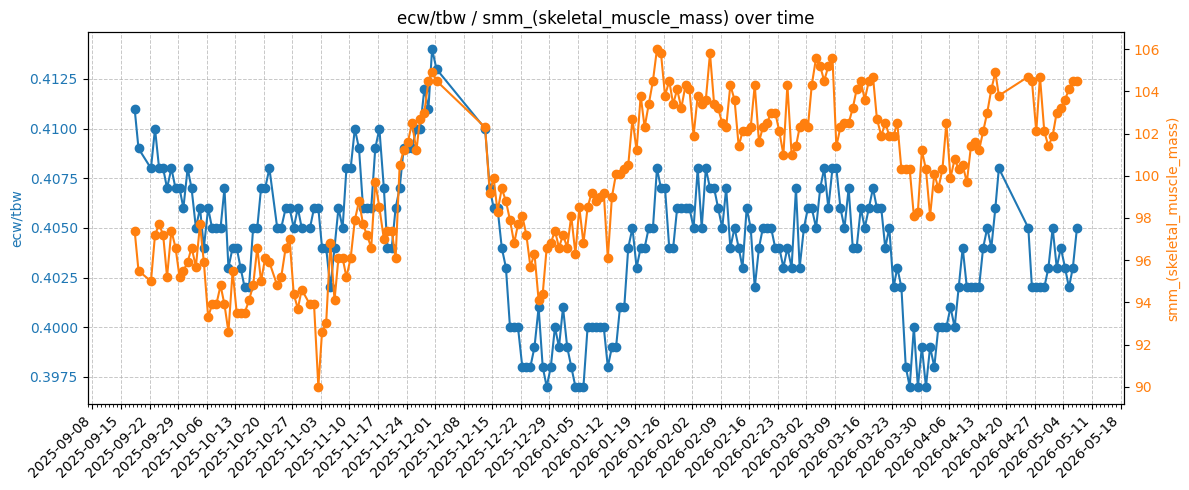

In [12]:
# Plots by subject weighth distribution
plt_lst = ["ecw/tbw","smm_(skeletal_muscle_mass)"]
#plt_lst = ['weight']
plot_multi_dual(df_77_97_mrn, *plt_lst )

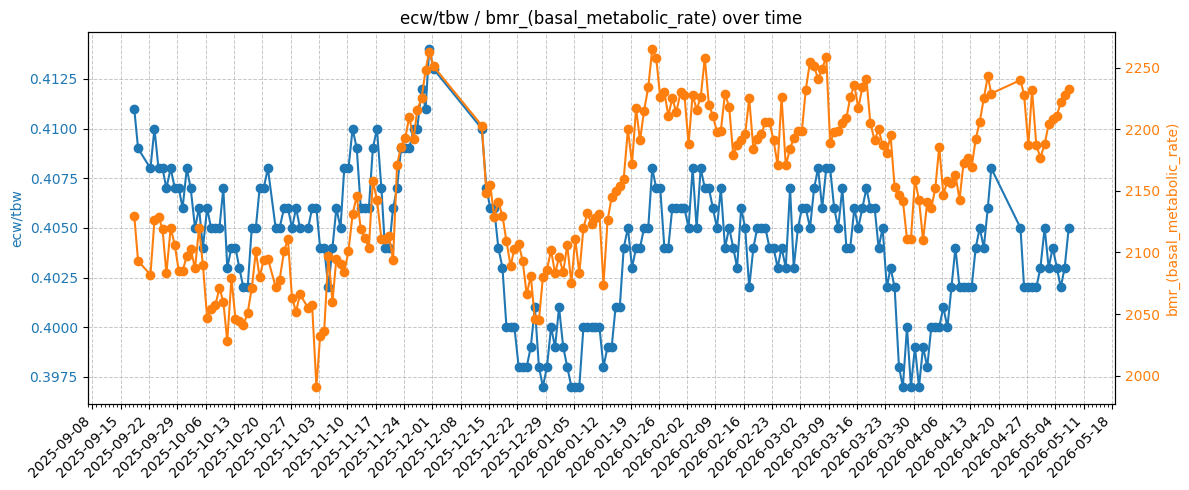

In [13]:
# Plots by subject inflamation and BMR
plt_lst = ["ecw/tbw", 'bmr_(basal_metabolic_rate)']
plot_multi_dual(df_77_97_mrn, *plt_lst )

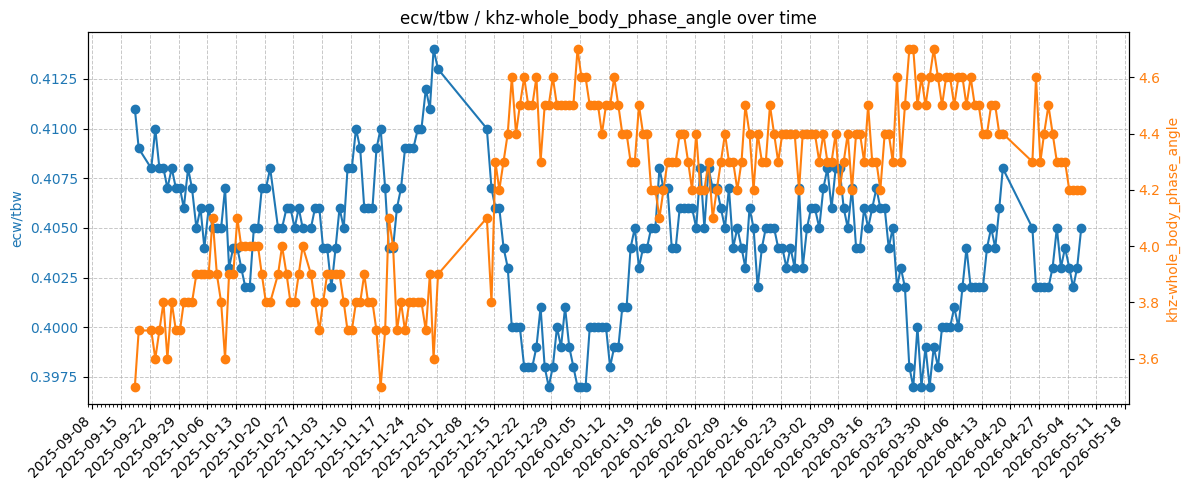

In [21]:
# Plots by subject
plt_lst = ["ecw/tbw",'khz-whole_body_phase_angle']
plot_multi_dual(df_77_97_mrn, *plt_lst )

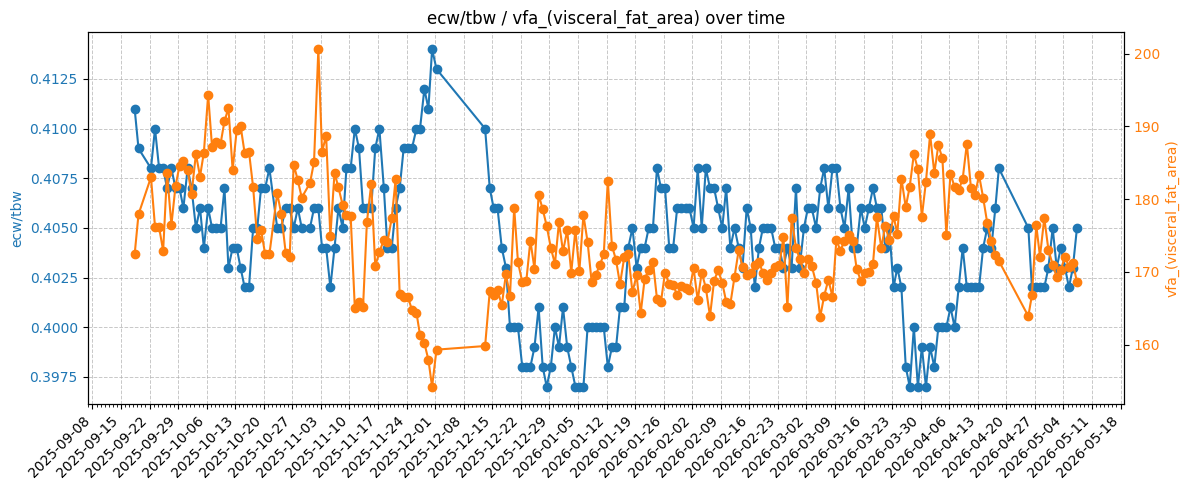

In [22]:
# Plots by subject
plt_lst = ["ecw/tbw","vfa_(visceral_fat_area)"]
plot_multi_dual(df_77_97_mrn, *plt_lst)

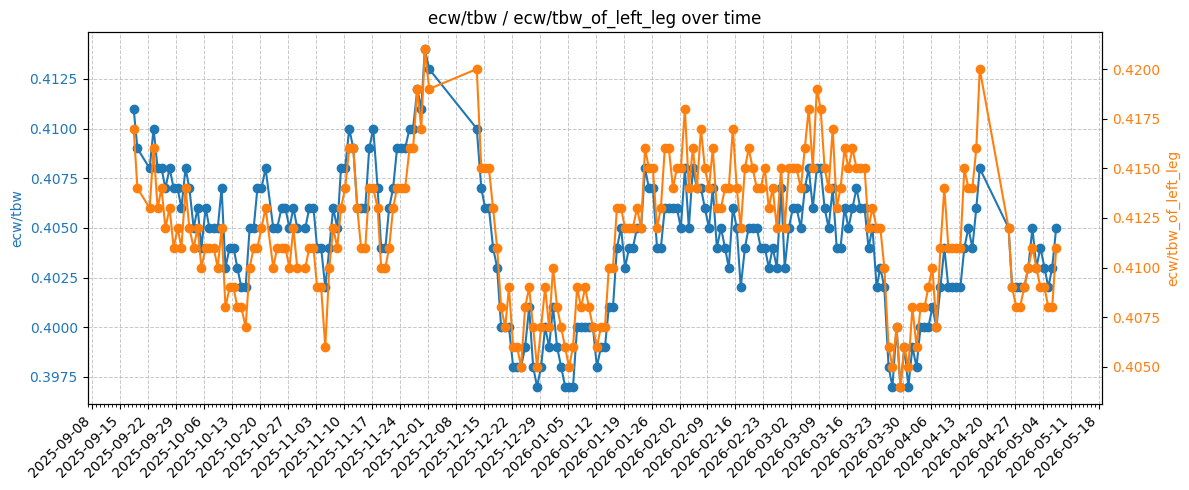

In [23]:
# Plots by subject
plt_lst = ["ecw/tbw","ecw/tbw_of_left_leg"]
plot_multi_dual(df_77_97_mrn, *plt_lst )

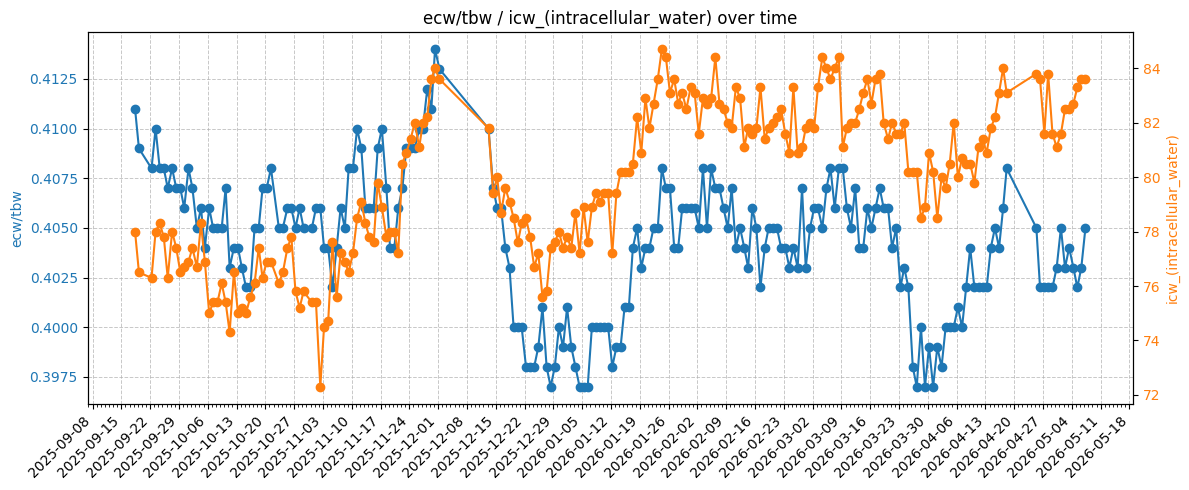

In [24]:
# Plots by subject
plt_lst = plt_lst = ["ecw/tbw",'icw_(intracellular_water)']
plot_multi_dual(df_77_97_mrn, *plt_lst)

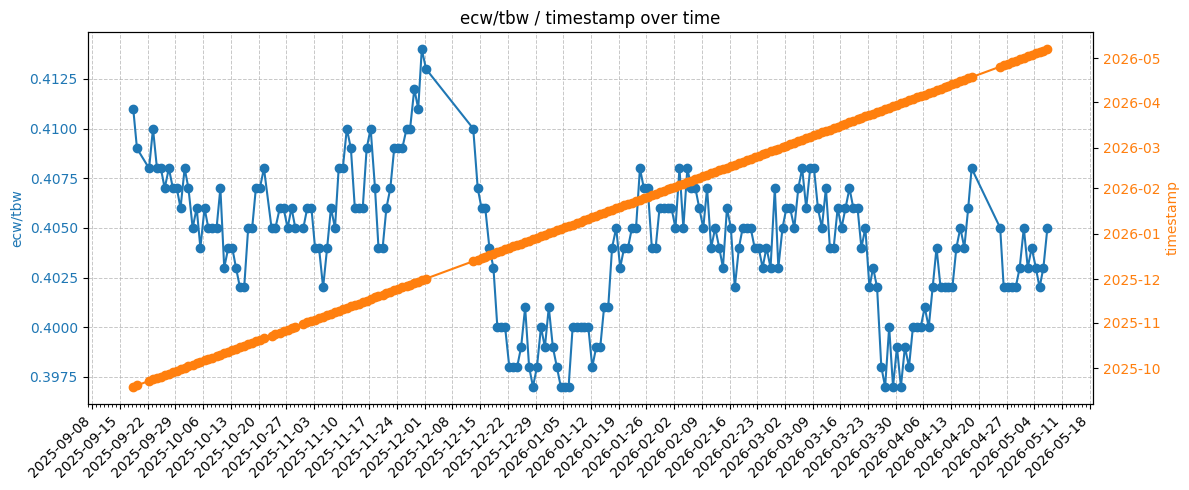

In [25]:
# Plots by subject
plt_lst = plt_lst = ["ecw/tbw",'timestamp']
plot_multi_dual(df_77_97_mrn, *plt_lst)